In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/used_cars.csv')

In [ ]:
# data cleaning
df = df[['model_year', 'milage', 'fuel_type',"accident", "price"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy(deep=True)
# df_new['price'] = df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float)
df_new['price'] = np.log(df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float))
df_new['milage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)

df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
data_year = 2023
df_new['age'] = data_year - df_new['model_year'].astype(int)
print(df_new.head())

   model_year   milage      fuel_type  accident      price  age
0        2013  51000.0  E85 Flex Fuel         1   9.239899   10
1        2021  34742.0       Gasoline         1  10.545473    2
2        2022  22372.0       Gasoline         0  10.907753    1
3        2015  88900.0         Hybrid         0   9.648595    8
4        2021   9835.0       Gasoline         0  10.463075    2


['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid']
Categories (5, object): ['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid']


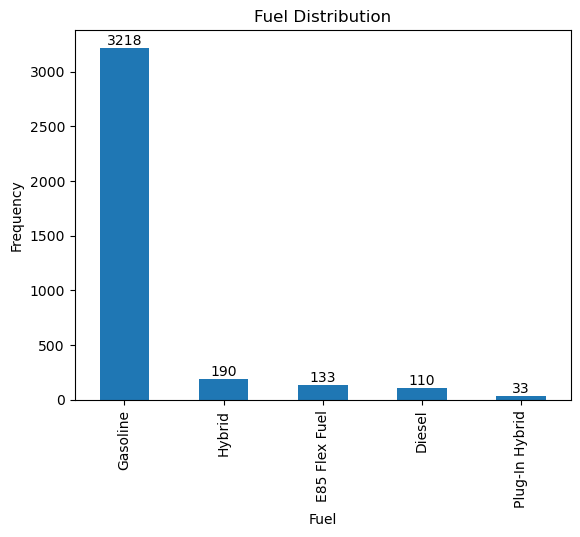

In [4]:
print(df_new['fuel_type'].unique())
counts = df_new["fuel_type"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Fuel Distribution')
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.show()

As we can see the number of cars in different groups are quite imbalanced. To make it slightly better we merge cars with Hybrid power, plug-in hybrid power and Flex fuel power as one catagory, and make Diesel the same category with gasoline.

In [5]:
# Create binary fuel_type: 0 = traditional, 1 = green
df_export = df_new.copy()
df_export["fuel_type"] = (~df_export["fuel_type"].isin(["Gasoline", "Diesel"])).astype(int)

# Select only needed columns
df_export = df_export[["milage", "accident", "fuel_type", "age", "price"]]

# Export
df_export.to_csv("data/cleaned.csv", index=False)

The following is some visualizations: 

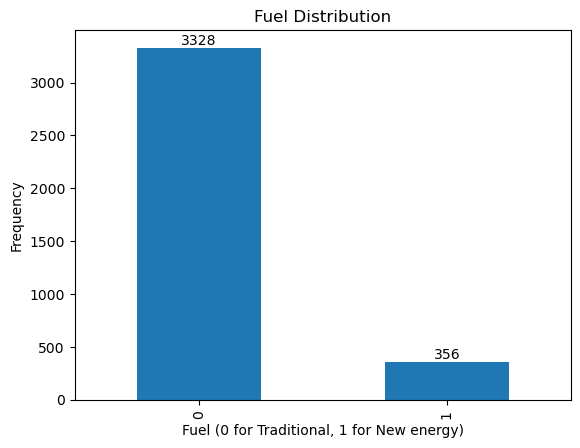

27


In [14]:
counts = df_export["fuel_type"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Fuel Distribution')
plt.xlabel('Fuel (0 for Traditional, 1 for New energy)')
plt.ylabel('Frequency')
plt.show()

print(max(df_export["age"]))

Text(0.5, 1.0, 'Accident vs logged Price')

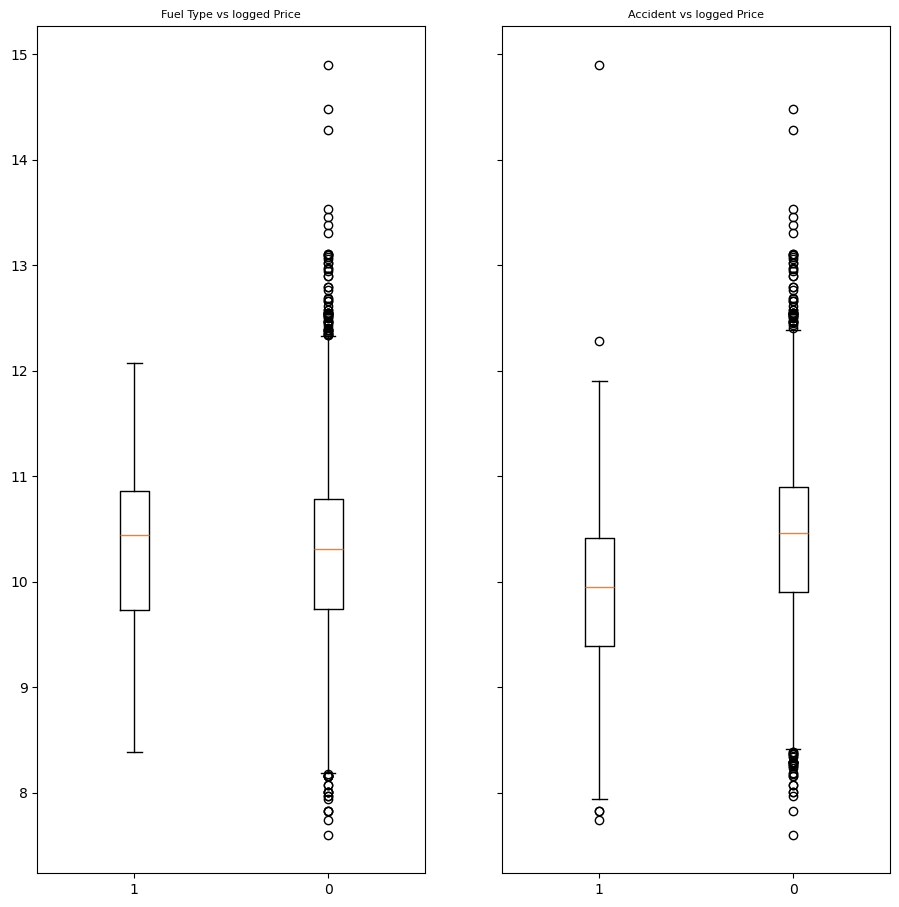

In [7]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11, 11), sharey=True)
# Boxplot of fuel type vs price:
fuel_types = df_export["fuel_type"].unique()
price_groups = [df_export[df_export["fuel_type"] == ft]["price"] for ft in fuel_types]

axs[0].boxplot(price_groups, tick_labels=fuel_types)
axs[0].set_title('Fuel Type vs logged Price', fontsize=8)
# Boxplot of accident vs price:
accident_types = df_export["accident"].unique()
price_groups_acc = [df_export[df_export["accident"] == ac]["price"] for ac in accident_types]

axs[1].boxplot(price_groups_acc, tick_labels=accident_types)
axs[1].set_title('Accident vs logged Price', fontsize=8)

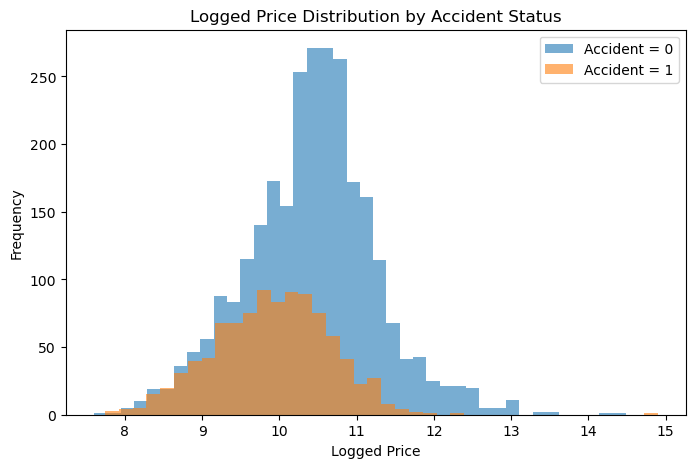

In [24]:
fig, ax = plt.subplots(figsize=(8,5))

price_no_acc = df_export[df_export["accident"] == 0]["price"]
price_acc    = df_export[df_export["accident"] == 1]["price"]

ax.hist(price_no_acc, bins=40, alpha=0.6, label="Accident = 0")
ax.hist(price_acc, bins=40, alpha=0.6, label="Accident = 1")

ax.set_title("Logged Price Distribution by Accident Status")
ax.set_xlabel("Logged Price")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

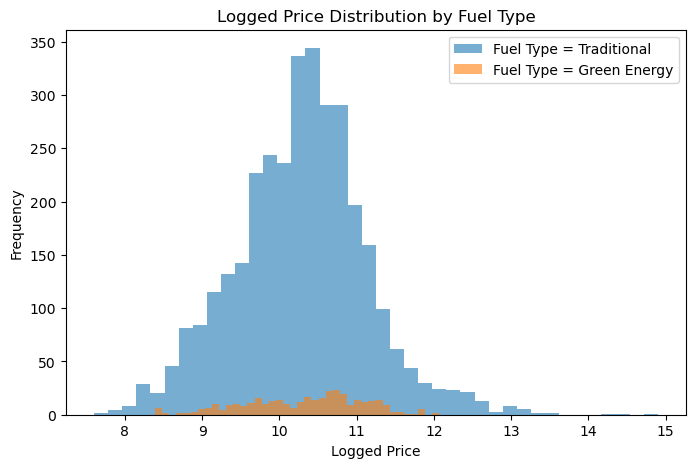

In [26]:
fig, ax = plt.subplots(figsize=(8,5))

price_no_acc = df_export[df_export["fuel_type"] == 0]["price"]
price_acc    = df_export[df_export["fuel_type"] == 1]["price"]

ax.hist(price_no_acc, bins=40, alpha=0.6, label="Fuel Type = Traditional")
ax.hist(price_acc, bins=40, alpha=0.6, label="Fuel Type = Green Energy")

ax.set_title("Logged Price Distribution by Fuel Type")
ax.set_xlabel("Logged Price")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

The mean of logged price between two fuel groups are not so different, let's check their variance:

In [8]:
print(df_export.groupby("fuel_type")["price"].var())
print(df_export.groupby("fuel_type")["price"].mean())

fuel_type
0    0.738190
1    0.596797
Name: price, dtype: float64
fuel_type
0    10.279762
1    10.317478
Name: price, dtype: float64


How about the accident groups?

In [9]:
print(df_export.groupby("accident")["price"].var())
print(df_export.groupby("accident")["price"].mean())

accident
0    0.711428
1    0.567139
Name: price, dtype: float64
accident
0    10.418242
1     9.904558
Name: price, dtype: float64


Text(0.5, 1.0, 'Mileage vs. Logged New Energy Car Price')

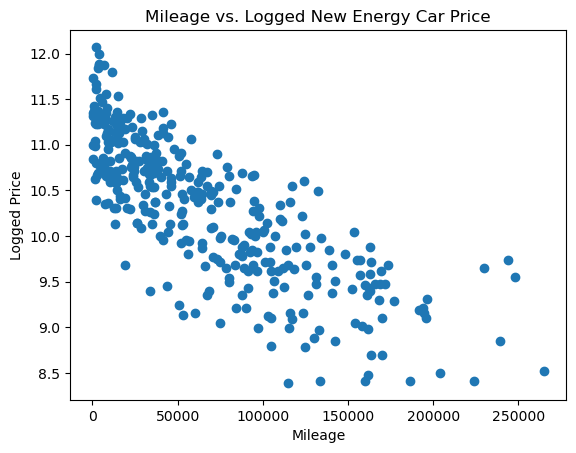

In [10]:
# Visualization part 2:
# Scatter plot of Mileage vs price:
# plt.boxplot(df_new["price"])
# plt.xlabel("Price")
# plt.title("Logged Car Price Boxplot")

plt.scatter(df_export[df_export['fuel_type']==fuel_types[0]]['milage'], 
            df_export[df_export['fuel_type']==fuel_types[0]]['price'])
plt.xlabel("Mileage")
plt.ylabel("Logged Price")
plt.title("Mileage vs. Logged New Energy Car Price")



Text(0.5, 1.0, 'Mileage vs. Logged Traditional Car Price')

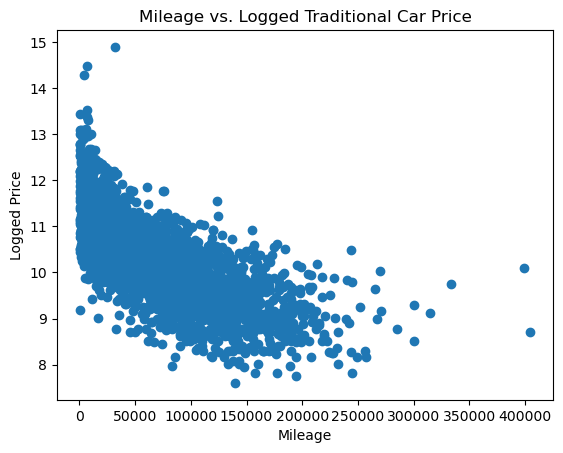

In [11]:
plt.scatter(df_export[df_export['fuel_type']==fuel_types[1]]['milage'], 
            df_export[df_export['fuel_type']==fuel_types[1]]['price'])
plt.xlabel("Mileage")
plt.ylabel("Logged Price")
plt.title("Mileage vs. Logged Traditional Car Price")


Text(0.5, 1.0, 'Car Age (Binned) vs Price')

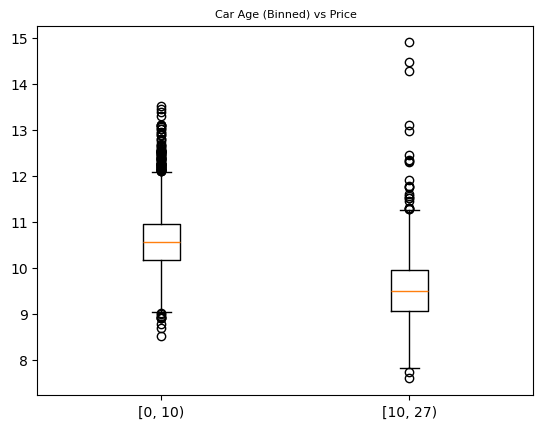

In [18]:
# Boxplot of Car Age vs Price
df_export["age_bin"] = pd.cut(df_export["age"], bins=[0, 10, 27], right=False)

age_types = df_export["age_bin"].cat.categories
price_groups = [df_export[df_export["age_bin"] == b]["price"] for b in age_types]

plt.boxplot(price_groups, tick_labels=age_types)
plt.title('Car Age (Binned) vs Price', fontsize=8)

In [19]:
print(df_export.groupby("age_bin", observed=True)["price"].count())
print("\n Variance: \n")
print(df_export.groupby("age_bin", observed=True)["price"].var())
print("\n  Mean: \n")
print(df_export.groupby("age_bin", observed=True)["price"].mean())

age_bin
[0, 10)     2549
[10, 27)    1125
Name: price, dtype: int64

 Variance: 

age_bin
[0, 10)     0.442845
[10, 27)    0.611328
Name: price, dtype: float64

  Mean: 

age_bin
[0, 10)     10.600489
[10, 27)     9.561875
Name: price, dtype: float64
